# Assignment 4: Decision Tree Model and Business Interpretation

## FreshBasket Subscription Grocery Delivery - Customer Churn Prediction

**Course:** MBAI 5310G - AI Programming  
**Model:** Decision Tree Classifier  
**Target Variable:** `Churned`  
**Positive Class:** `Yes` = customer churned

## 1. Business Problem Understanding

FreshBasket is a subscription-based grocery delivery service operating in the Greater Toronto Area. The company earns revenue through recurring subscriptions and regular grocery orders. Therefore, customer retention is very important.

The main business problem is customer churn. FreshBasket wants to identify customers who are likely to cancel or not renew their subscription before they leave.

A Decision Tree classification model can help the business decide which customers should receive proactive retention attention, such as customer support follow-up, delivery issue investigation, app engagement reminders, or targeted offers.

The target variable is `Churned`. The input features include customer profile, region, subscription type, payment method, delivery window, spending, recent orders, delivery issues, customer service tickets, discount use, app engagement, and satisfaction score.

This prediction is useful because it helps FreshBasket prioritize limited customer support and marketing resources toward customers who are more likely to churn.

## 2. Import Required Libraries

In [1]:
# Import warnings library to hide non-critical Excel formatting warnings
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

# Import pathlib to manage file paths
from pathlib import Path

# Import pandas and numpy for data handling
import pandas as pd
import numpy as np

# Import matplotlib for charts
import matplotlib.pyplot as plt

# Import machine learning tools from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Create the outputs folder if it does not already exist
outputs_dir = Path("outputs")
outputs_dir.mkdir(exist_ok=True)

print("Libraries imported successfully!")

Libraries imported successfully!


## 3. Load the Dataset

In [2]:
# Store the dataset file name in a variable
# Keep this dataset in the same folder as the notebook
file_path = "freshbasket_customer_churn_dataset.xlsx"

# Load the Dataset sheet from the Excel file
df = pd.read_excel(file_path, sheet_name="Dataset")

# Confirm that the dataset loaded successfully
print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

# Display the first five rows
display(df.head())

Dataset loaded successfully!
Dataset shape: (425, 16)


,Customer_ID,Age_Group,Region,Subscription_Type,Payment_Method,Delivery_Window,Membership_Length_Months,Monthly_Spend,Average_Order_Value,Orders_Last_3_Months,Delivery_Issues_Last_3_Months,Customer_Service_Tickets,Discount_Used,App_Engagement_Score,Satisfaction_Score,Churned
0,FB-1001,18-24,Toronto,Family,Credit Card,Evening,18,267.23,140.14,9,0,0,No,70.0,3.0,No
1,FB-1002,45-54,Toronto,Premium,Credit Card,Morning,7,349.36,179.20,10,1,1,No,14.0,3.0,Yes
2,FB-1003,35-44,Mississauga,Basic,Credit Card,Morning,4,132.08,25.00,6,0,0,Yes,46.0,3.0,No
3,FB-1004,35-44,Ajax,Basic,Credit Card,Afternoon,8,80.71,25.00,0,1,0,Yes,42.0,5.0,Yes
4,FB-1005,45-54,Markham,Family,Credit Card,Morning,21,218.95,31.10,1,0,0,No,88.0,3.0,No


## 4. Inspect the Dataset

In [3]:
# Check the number of rows and columns
print("Number of rows and columns:")
print(df.shape)

# Print the column names
print("\nColumn names:")
print(df.columns.tolist())

# Check data types
print("\nData types:")
print(df.dtypes)

# Display basic information about the dataset
print("\nDataset information:")
df.info()

Number of rows and columns:
(425, 16)

Column names:
['Customer_ID', 'Age_Group', 'Region', 'Subscription_Type', 'Payment_Method', 'Delivery_Window', 'Membership_Length_Months', 'Monthly_Spend', 'Average_Order_Value', 'Orders_Last_3_Months', 'Delivery_Issues_Last_3_Months', 'Customer_Service_Tickets', 'Discount_Used', 'App_Engagement_Score', 'Satisfaction_Score', 'Churned']

Data types:
Customer_ID                          str
Age_Group                            str
Region                               str
Subscription_Type                    str
Payment_Method                       str
Delivery_Window                      str
Membership_Length_Months           int64
Monthly_Spend                    float64
Average_Order_Value              float64
Orders_Last_3_Months               int64
Delivery_Issues_Last_3_Months      int64
Customer_Service_Tickets           int64
Discount_Used                        str
App_Engagement_Score             float64
Satisfaction_Score               flo

## 5. Check Missing Values and Duplicate Rows

In [4]:
# Check missing values before cleaning
missing_before = df.isna().sum()

print("Missing values before handling:")
print(missing_before[missing_before > 0])

# Check duplicate rows before cleaning
duplicate_rows_before = df.duplicated().sum()
print("\nDuplicate rows before cleaning:", duplicate_rows_before)

# Check target variable distribution before cleaning
print("\nTarget variable distribution before cleaning:")
print(df["Churned"].value_counts())

Missing values before handling:
Region                  9
Monthly_Spend           6
App_Engagement_Score    4
Satisfaction_Score      6
dtype: int64

Duplicate rows before cleaning: 5

Target variable distribution before cleaning:
Churned
No     307
Yes    118
Name: count, dtype: int64


## 6. Clean the Dataset

Duplicate rows are removed before modelling. Missing values are **not** filled directly in the full dataset. They are handled later inside the preprocessing pipeline after the train-test split. This helps reduce data leakage risk.

In [5]:
# Remove exact duplicate rows
df_clean = df.drop_duplicates().copy()

# Check duplicate rows after cleaning
duplicate_rows_after = df_clean.duplicated().sum()

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)
print("Duplicate rows before cleaning:", duplicate_rows_before)
print("Duplicate rows after cleaning:", duplicate_rows_after)

# Check target distribution after cleaning
print("\nTarget variable distribution after cleaning:")
target_distribution = df_clean["Churned"].value_counts().reindex(["No", "Yes"])
print(target_distribution)

Original dataset shape: (425, 16)
Cleaned dataset shape: (420, 16)
Duplicate rows before cleaning: 5
Duplicate rows after cleaning: 0

Target variable distribution after cleaning:
Churned
No     304
Yes    116
Name: count, dtype: int64


## 7. Chart: Target Variable Distribution

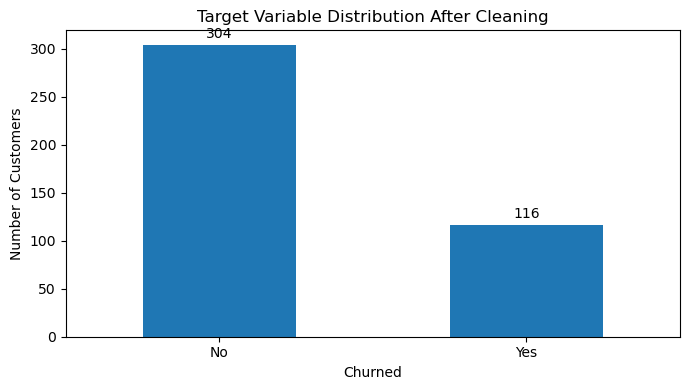

In [6]:
# Create a bar chart for the target distribution
ax = target_distribution.plot(
    kind="bar",
    figsize=(7, 4)
)

# Add chart title and labels
plt.title("Target Variable Distribution After Cleaning")
plt.xlabel("Churned")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

# Add numbers on the bars
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Adjust layout and save chart
plt.tight_layout()
plt.savefig(outputs_dir / "target_distribution_after_cleaning.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

## 8. Chart: Missing Values by Column

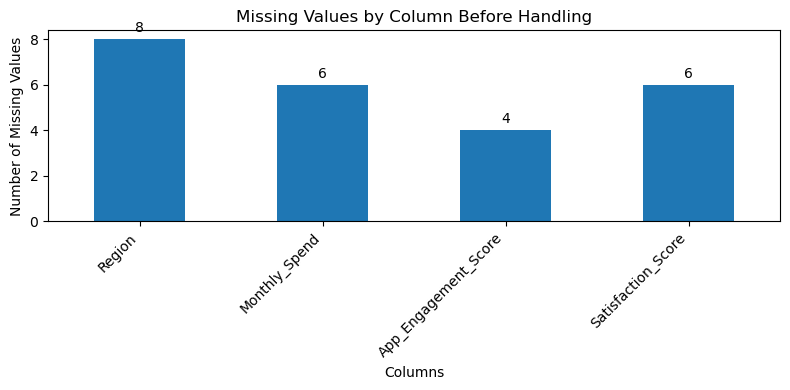

In [7]:
# Check missing values after duplicate removal
missing_after_duplicate_removal = df_clean.isna().sum()

# Select only columns that have missing values
missing_columns = missing_after_duplicate_removal[missing_after_duplicate_removal > 0]

# Create a bar chart for missing values
ax = missing_columns.plot(
    kind="bar",
    figsize=(8, 4)
)

# Add chart title and labels
plt.title("Missing Values by Column Before Handling")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45, ha="right")

# Add numbers on the bars
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Adjust layout and save chart
plt.tight_layout()
plt.savefig(outputs_dir / "missing_values_by_column.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

## 9. Separate Features and Target Variable

In [8]:
# Separate the target variable from the input features
# Customer_ID is removed because it is only an identifier and should not be used for prediction
X = df_clean.drop(columns=["Customer_ID", "Churned"])
y = df_clean["Churned"]

# Display the shapes of X and y
print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)

# Display first five rows of X
display(X.head())

Feature matrix X shape: (420, 14)
Target vector y shape: (420,)


,Age_Group,Region,Subscription_Type,Payment_Method,Delivery_Window,Membership_Length_Months,Monthly_Spend,Average_Order_Value,Orders_Last_3_Months,Delivery_Issues_Last_3_Months,Customer_Service_Tickets,Discount_Used,App_Engagement_Score,Satisfaction_Score
0,18-24,Toronto,Family,Credit Card,Evening,18,267.23,140.14,9,0,0,No,70.0,3.0
1,45-54,Toronto,Premium,Credit Card,Morning,7,349.36,179.20,10,1,1,No,14.0,3.0
2,35-44,Mississauga,Basic,Credit Card,Morning,4,132.08,25.00,6,0,0,Yes,46.0,3.0
3,35-44,Ajax,Basic,Credit Card,Afternoon,8,80.71,25.00,0,1,0,Yes,42.0,5.0
4,45-54,Markham,Family,Credit Card,Morning,21,218.95,31.10,1,0,0,No,88.0,3.0


## 10. Identify Numerical and Categorical Features

In [9]:
# Select numerical feature columns from X
numerical_features = X.select_dtypes(include=["number"]).columns.tolist()

# Select categorical feature columns from X
categorical_features = [col for col in X.columns if col not in numerical_features]

# Print numerical features
print("Numerical features:")
print(numerical_features)

# Print a separator line
print("-" * 50)

# Print categorical features
print("Categorical features:")
print(categorical_features)

Numerical features:
['Membership_Length_Months', 'Monthly_Spend', 'Average_Order_Value', 'Orders_Last_3_Months', 'Delivery_Issues_Last_3_Months', 'Customer_Service_Tickets', 'App_Engagement_Score', 'Satisfaction_Score']
--------------------------------------------------
Categorical features:
['Age_Group', 'Region', 'Subscription_Type', 'Payment_Method', 'Delivery_Window', 'Discount_Used']


## 11. Chart: Number of Unique Values in Categorical Features

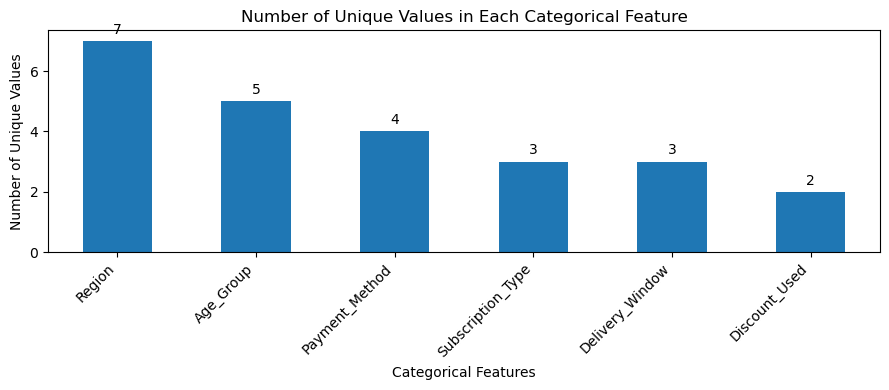

In [10]:
# Count unique values in each categorical feature
categorical_unique_counts = X[categorical_features].nunique().sort_values(ascending=False)

# Create a bar chart
ax = categorical_unique_counts.plot(
    kind="bar",
    figsize=(9, 4)
)

# Add chart title and labels
plt.title("Number of Unique Values in Each Categorical Feature")
plt.xlabel("Categorical Features")
plt.ylabel("Number of Unique Values")
plt.xticks(rotation=45, ha="right")

# Add numbers on the bars
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Adjust layout and save chart
plt.tight_layout()
plt.savefig(outputs_dir / "categorical_unique_values.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

## 12. Split the Data into Training and Testing Sets

In [11]:
# Split the dataset into training and testing sets
# stratify=y keeps a similar Yes/No distribution in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Print the shapes of the training and testing sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Check target distribution in train and test sets
print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

X_train shape: (336, 14)
X_test shape: (84, 14)
y_train shape: (336,)
y_test shape: (84,)

Training target distribution:
Churned
No     243
Yes     93
Name: count, dtype: int64

Testing target distribution:
Churned
No     61
Yes    23
Name: count, dtype: int64


## 13. Chart: Training Set vs Testing Set Size

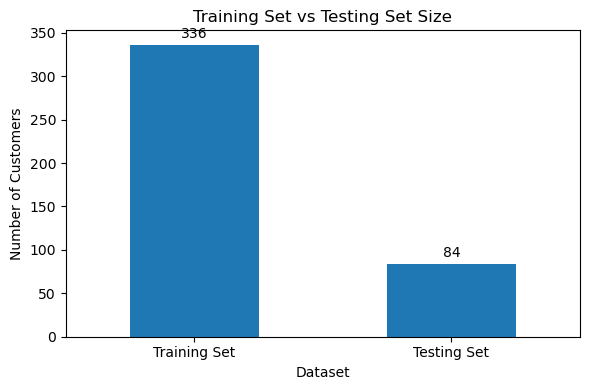

In [12]:
# Create a series for training and testing set sizes
split_counts = pd.Series({
    "Training Set": len(X_train),
    "Testing Set": len(X_test)
})

# Create the bar chart
ax = split_counts.plot(
    kind="bar",
    figsize=(6, 4)
)

# Add chart title and labels
plt.title("Training Set vs Testing Set Size")
plt.xlabel("Dataset")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

# Add numbers on the bars
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Adjust layout and save chart
plt.tight_layout()
plt.savefig(outputs_dir / "training_testing_size.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

## 14. Build the Preprocessing Pipeline

The preprocessing steps are fitted only on the training data inside the pipeline. This is better than filling missing values before the train-test split because it reduces data leakage risk.

In [13]:
# Create the numerical transformer
# Numerical missing values are filled using the median
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Create the categorical transformer
# Categorical missing values are filled using the most frequent value
# One-hot encoding converts categorical variables into numeric columns
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


## 15. Train the Decision Tree Classification Model

The Decision Tree is controlled using `max_depth`, `min_samples_leaf`, and `class_weight`. These settings help keep the model interpretable, reduce overfitting risk, and improve attention to the smaller churned class.

In [14]:
# Create the Decision Tree classifier
# class_weight="balanced" gives more attention to the smaller churned class
# max_depth and min_samples_leaf help reduce overfitting
decision_tree = DecisionTreeClassifier(
    max_depth=7,
    min_samples_leaf=15,
    class_weight="balanced",
    random_state=42
)

# Create the full model pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", decision_tree)
])

# Train the model using the training data
model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


## 16. Make Predictions

In [15]:
# Make predictions on the testing data
y_pred = model.predict(X_test)

# Make predictions on the training data for overfitting analysis
y_train_pred = model.predict(X_train)

# Create a table of sample actual and predicted values
sample_predictions = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

# Display the first 10 predictions
print("Sample actual and predicted values:")
display(sample_predictions.head(10))

Sample actual and predicted values:


,Actual,Predicted
0,No,No
1,No,No
2,No,Yes
3,No,No
4,No,No
5,Yes,Yes
6,Yes,No
7,No,No
8,No,No
9,No,No


## 17. Actual vs Predicted Class Counts

,Actual,Predicted
No,61,56
Yes,23,28


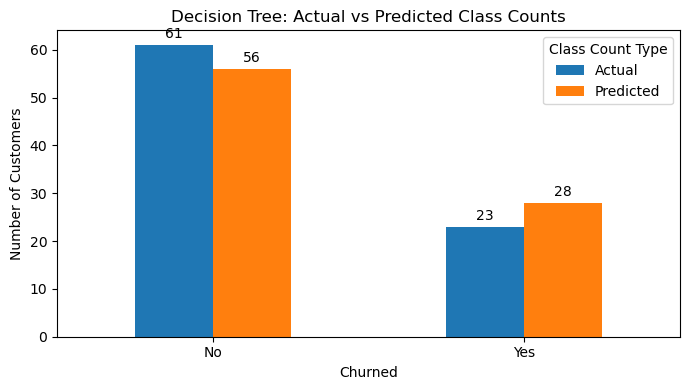

In [16]:
# Create actual and predicted class count comparison
class_count_comparison = pd.DataFrame({
    "Actual": y_test.value_counts().reindex(["No", "Yes"]),
    "Predicted": pd.Series(y_pred).value_counts().reindex(["No", "Yes"])
}).fillna(0).astype(int)

# Display the comparison table
display(class_count_comparison)

# Create a bar chart for actual and predicted class counts
ax = class_count_comparison.plot(
    kind="bar",
    figsize=(7, 4)
)

# Add a title to the chart
plt.title("Decision Tree: Actual vs Predicted Class Counts")

# Add a label to the x-axis
plt.xlabel("Churned")

# Add a label to the y-axis
plt.ylabel("Number of Customers")

# Rotate x-axis labels
plt.xticks(rotation=0)

# Add legend title
plt.legend(title="Class Count Type")

# Add numbers on the bars
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Adjust the layout
plt.tight_layout()

# Save the chart
plt.savefig(outputs_dir / "actual_vs_predicted_class_counts.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

## 18. Calculate Evaluation Metrics

In [17]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=["No", "Yes"])

# Calculate evaluation metrics for the Yes class
accuracy = accuracy_score(y_test, y_pred)
precision_yes = precision_score(y_test, y_pred, pos_label="Yes", zero_division=0)
recall_yes = recall_score(y_test, y_pred, pos_label="Yes", zero_division=0)
f1_yes = f1_score(y_test, y_pred, pos_label="Yes", zero_division=0)

# Calculate training and testing accuracy
training_accuracy = accuracy_score(y_train, y_train_pred)
testing_accuracy = accuracy
accuracy_gap = training_accuracy - testing_accuracy

# Create a results table
results_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision for Yes", "Recall for Yes", "F1-score for Yes"],
    "Score": [accuracy, precision_yes, recall_yes, f1_yes],
    "Percentage": [accuracy * 100, precision_yes * 100, recall_yes * 100, f1_yes * 100]
})

# Display the results table
display(results_df)

# Print training and testing accuracy
print("Training accuracy:", round(training_accuracy, 4))
print("Testing accuracy:", round(testing_accuracy, 4))
print("Accuracy gap:", round(accuracy_gap, 4))

,Metric,Score,Percentage
0,Accuracy,0.726190,72.619048
1,Precision for Yes,0.500000,50.000000
2,Recall for Yes,0.608696,60.869565
3,F1-score for Yes,0.549020,54.901961


Training accuracy: 0.756
Testing accuracy: 0.7262
Accuracy gap: 0.0298


## 19. Chart: Evaluation Metrics

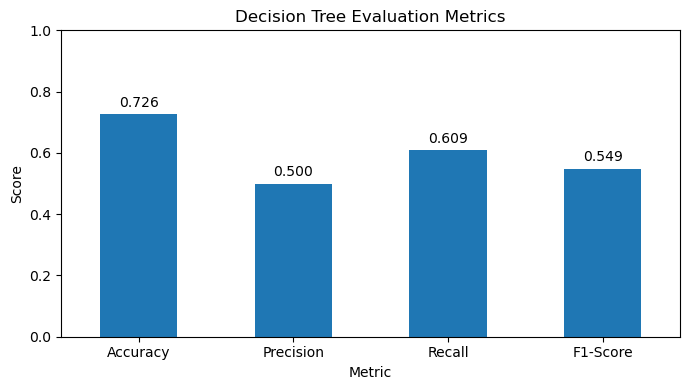

In [18]:
# Create a series for evaluation metrics
metric_scores = pd.Series({
    "Accuracy": accuracy,
    "Precision": precision_yes,
    "Recall": recall_yes,
    "F1-Score": f1_yes
})

# Create a bar chart
ax = metric_scores.plot(
    kind="bar",
    figsize=(7, 4)
)

# Add chart title and labels
plt.title("Decision Tree Evaluation Metrics")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

# Add score labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

# Adjust layout and save chart
plt.tight_layout()
plt.savefig(outputs_dir / "decision_tree_evaluation_metrics.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

## 20. Classification Report

In [19]:
# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, labels=["No", "Yes"], zero_division=0))

Classification Report:
              precision    recall  f1-score   support

          No       0.84      0.77      0.80        61
         Yes       0.50      0.61      0.55        23

    accuracy                           0.73        84
   macro avg       0.67      0.69      0.68        84
weighted avg       0.75      0.73      0.73        84



## 21. Confusion Matrix

,Predicted No,Predicted Yes
Actual No,47,14
Actual Yes,9,14


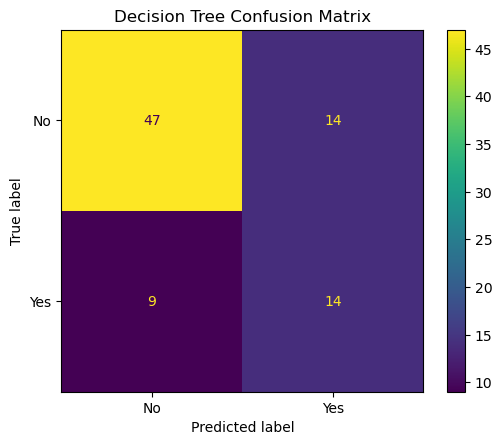

In [20]:
# Display confusion matrix values
confusion_matrix_df = pd.DataFrame(
    cm,
    index=["Actual No", "Actual Yes"],
    columns=["Predicted No", "Predicted Yes"]
)

display(confusion_matrix_df)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(5.5, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot(values_format="d", ax=ax, colorbar=True)
plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.savefig(outputs_dir / "decision_tree_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## 22. Business Interpretation of the Confusion Matrix

In this dataset, the positive class is `Yes`, meaning the customer churned.

- **True Negative:** The model correctly predicts that a customer did not churn.
- **False Positive:** The model predicts that a customer churned, but the customer did not actually churn. The business may spend unnecessary retention resources.
- **False Negative:** The model predicts that a customer did not churn, but the customer actually churned. The business may fail to help an at-risk customer and lose recurring revenue.
- **True Positive:** The model correctly predicts that a customer churned. The business can prioritize this customer for retention action.

For FreshBasket, false negatives are especially important because missing churned customers may lead to lost subscription revenue.

## 23. Feature Importance

In [21]:
# Get processed feature names after one-hot encoding
processed_feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Clean the feature names by removing transformer prefixes
processed_feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in processed_feature_names
]

# Get feature importance values from the Decision Tree
feature_importance_values = model.named_steps["classifier"].feature_importances_

# Create a feature importance DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": processed_feature_names,
    "Importance": feature_importance_values
}).sort_values(by="Importance", ascending=False)

# Display the top 10 features
print("Top 10 important features:")
display(feature_importance_df.head(10))

Top 10 important features:


,Feature,Importance
7,Satisfaction_Score,3.594620e-01
1,Monthly_Spend,2.424818e-01
3,Orders_Last_3_Months,1.575470e-01
6,App_Engagement_Score,1.354837e-01
2,Average_Order_Value,4.694256e-02
9,Age_Group_25-34,4.277758e-02
31,Discount_Used_Yes,1.530526e-02
0,Membership_Length_Months,1.312941e-15
22,Subscription_Type_Premium,4.718380e-16
8,Age_Group_18-24,0.000000e+00


## 24. Chart: Top 10 Feature Importances

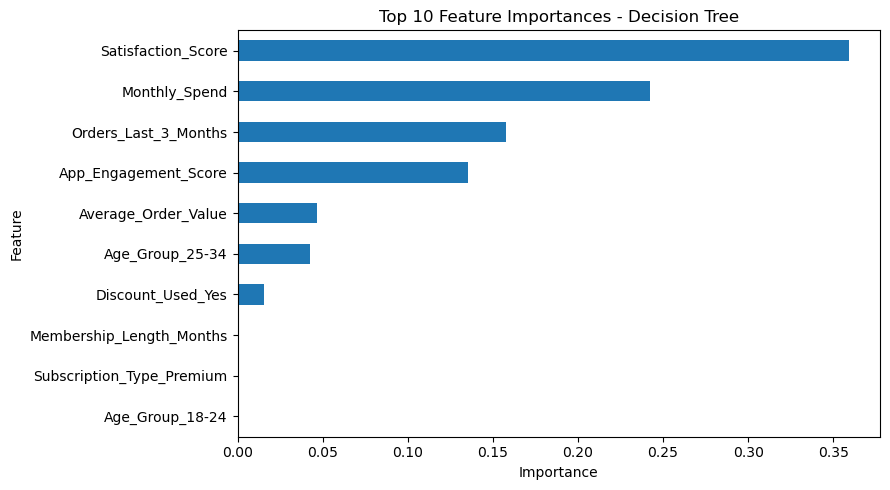

In [22]:
# Select the top 10 important features
top_10_features = feature_importance_df.head(10).sort_values(by="Importance", ascending=True)

# Create a horizontal bar chart
ax = top_10_features.plot(
    kind="barh",
    x="Feature",
    y="Importance",
    legend=False,
    figsize=(9, 5)
)

# Add chart title and labels
plt.title("Top 10 Feature Importances - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")

# Adjust layout and save chart
plt.tight_layout()
plt.savefig(outputs_dir / "top_10_feature_importance.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

## 25. Business Interpretation of Important Features

The most important features are connected to satisfaction, monthly spend, recent order activity, app engagement, average order value, age group, discount use, membership length, and subscription type.

These features can help FreshBasket make better decisions. For example, customers with low satisfaction may need service recovery. Customers with fewer recent orders may need personalized reminders or product recommendations. Customers with low app engagement may need easier ordering support or app reminders.

Feature importance does not prove direct causation. It shows which variables helped the Decision Tree make its splits, so the results should be used as decision-support insights.

## 26. Overfitting Check

,Evaluation Set,Accuracy,Percentage
0,Training Set,0.755952,75.595238
1,Testing Set,0.726190,72.619048
2,Difference,0.029762,2.976190


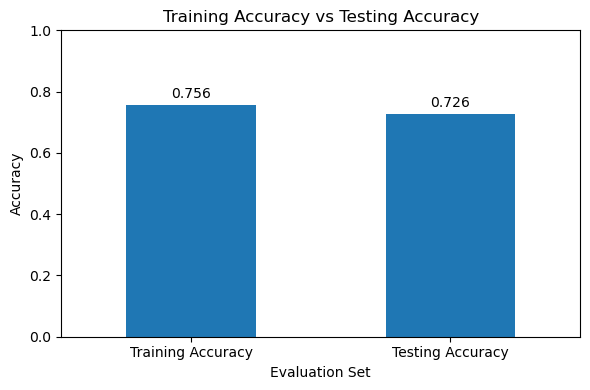

In [23]:
# Create a table comparing training and testing accuracy
accuracy_comparison = pd.DataFrame({
    "Evaluation Set": ["Training Set", "Testing Set", "Difference"],
    "Accuracy": [training_accuracy, testing_accuracy, accuracy_gap],
    "Percentage": [training_accuracy * 100, testing_accuracy * 100, accuracy_gap * 100]
})

# Display the table
display(accuracy_comparison)

# Create a bar chart comparing training and testing accuracy
accuracy_plot_data = pd.Series({
    "Training Accuracy": training_accuracy,
    "Testing Accuracy": testing_accuracy
})

ax = accuracy_plot_data.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Training Accuracy vs Testing Accuracy")
plt.xlabel("Evaluation Set")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)

# Add labels on the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.savefig(outputs_dir / "training_testing_accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 27. Overfitting Interpretation

The training accuracy is higher than the testing accuracy, but the gap is relatively small. This suggests that the selected Decision Tree does not show strong signs of overfitting.

The settings `max_depth=7` and `min_samples_leaf=15` help prevent the tree from becoming too complex. The model is still imperfect, so it should be treated as a decision-support tool rather than a final automatic decision system.

## 28. Decision Tree Visualization

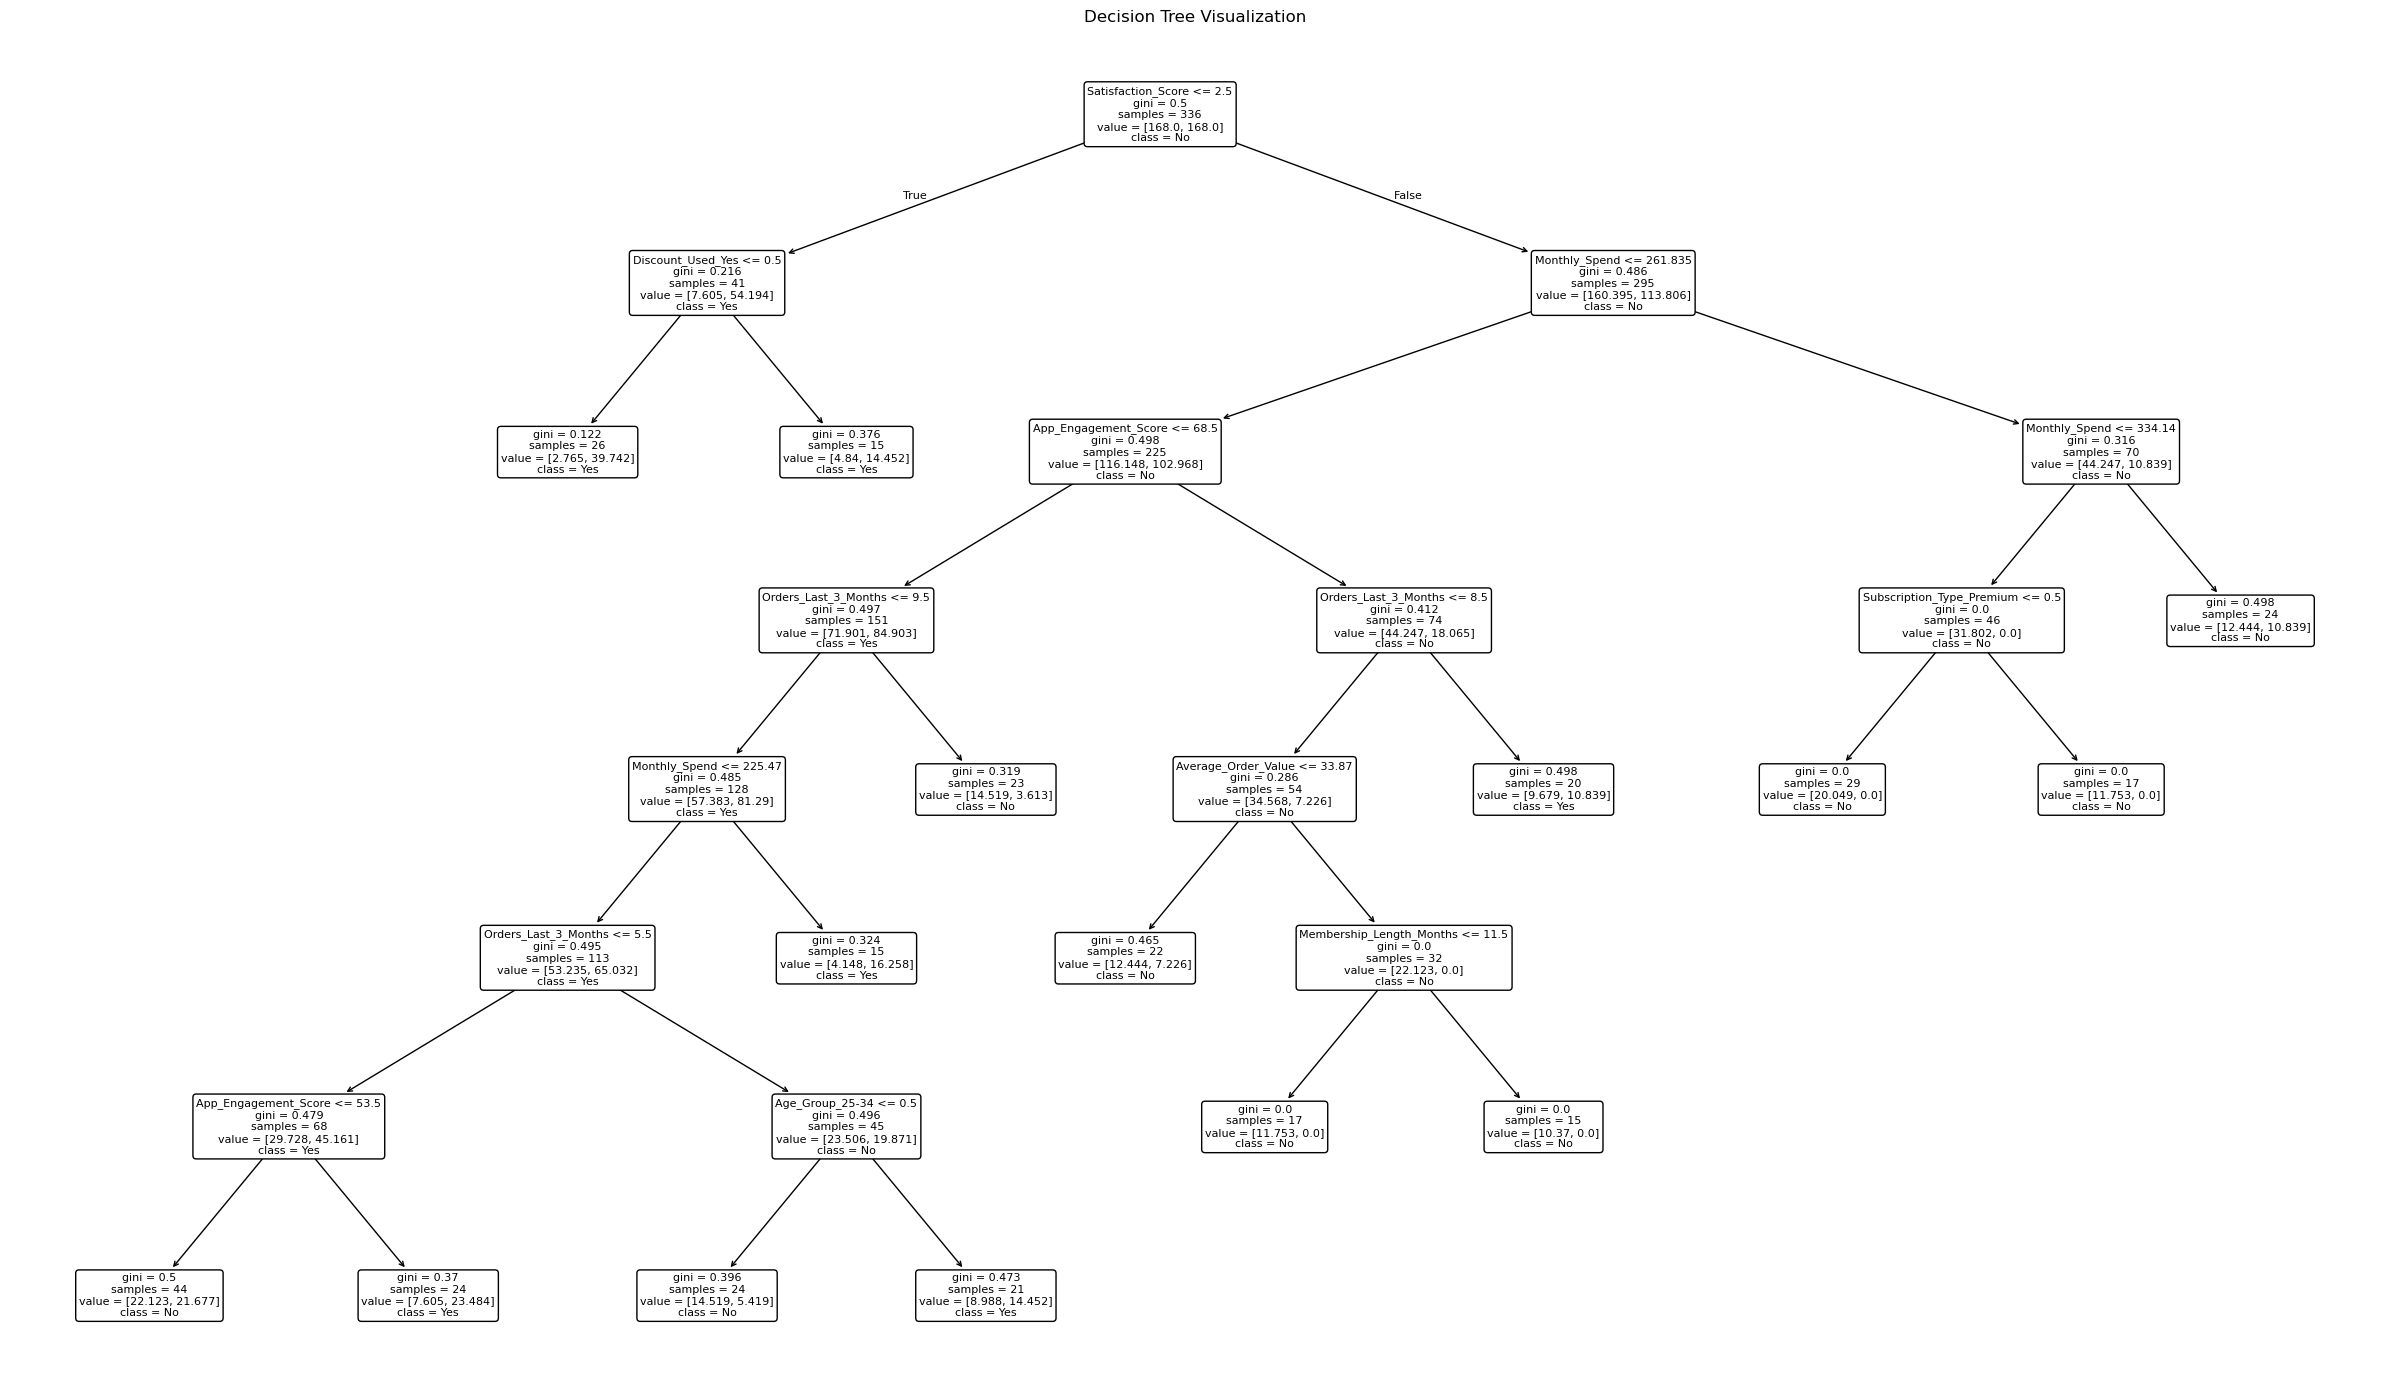

In [24]:
# Create a visualization of the trained Decision Tree
plt.figure(figsize=(24, 14))

plot_tree(
    model.named_steps["classifier"],
    feature_names=processed_feature_names,
    class_names=["No", "Yes"],
    filled=False,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Visualization")
plt.tight_layout()
plt.savefig(outputs_dir / "decision_tree_visualization.png", dpi=300, bbox_inches="tight")
plt.show()

## 29. Final Business Interpretation

The Decision Tree model provides useful support for FreshBasket's customer retention decisions. The model achieved a reasonable testing accuracy and identified a meaningful share of churned customers.

For this business problem, **recall for the Yes class** is the most important metric because missed churned customers may not receive support before leaving. A false positive may waste some retention resources, but a false negative may result in lost recurring revenue.

The important features suggest that customer satisfaction, monthly spend, recent order activity, app engagement, order value, age group, discount use, membership length, and subscription type are useful signals for churn risk. FreshBasket can use these insights to improve customer service, encourage app engagement, review declining order activity, and target retention actions more carefully.

One limitation is that the dataset is synthetic and simplified. It may not capture all real reasons for customer churn, such as income changes, competitor prices, product quality, family needs, or moving to another location. Human judgment should still be used to review customer context, avoid unfair treatment, and choose appropriate retention actions.

## 30. Save Key Results

In [25]:
# Save model evaluation results as CSV files
results_df.to_csv(outputs_dir / "model_evaluation_metrics.csv", index=False)
feature_importance_df.head(10).to_csv(outputs_dir / "top_10_feature_importance.csv", index=False)
confusion_matrix_df.to_csv(outputs_dir / "confusion_matrix.csv")
accuracy_comparison.to_csv(outputs_dir / "training_testing_accuracy_comparison.csv", index=False)

print("All key results and charts were saved in the outputs folder.")

All key results and charts were saved in the outputs folder.
